In [47]:
import geopandas as gpd
import matplotlib.pyplot as plt
from geodatasets import get_path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

In [48]:
spaces = pd.read_csv("Privately_Owned_Public_Spaces__POPS__20250310.csv")
spaces = spaces.dropna(subset=["Latitude", "Longitude"])

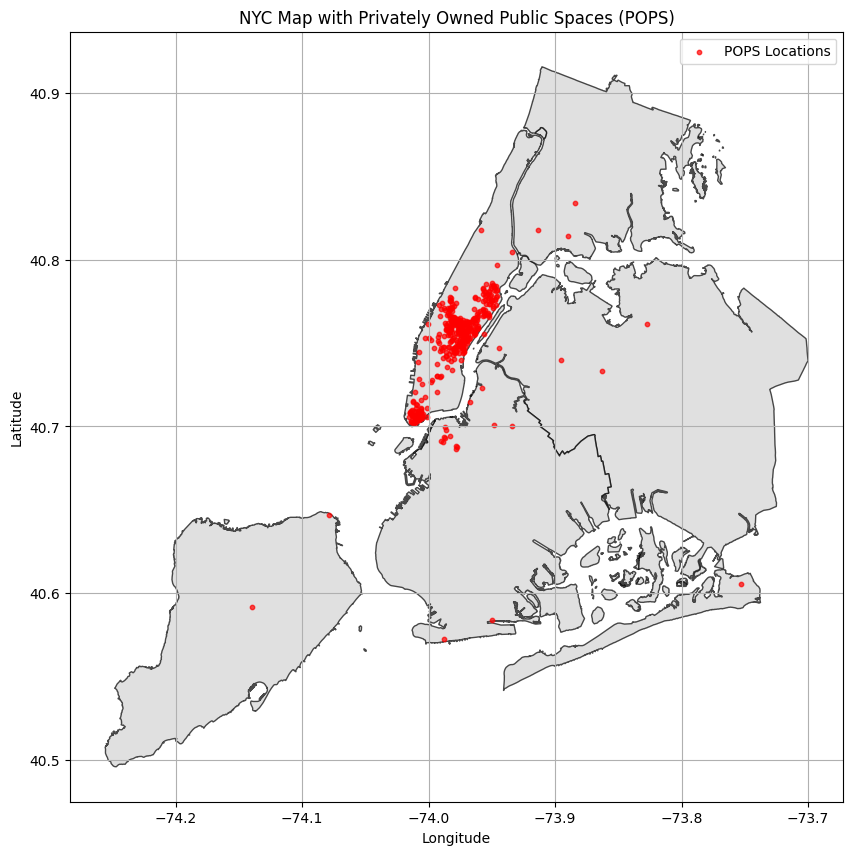

In [49]:
gdf_points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(spaces["Longitude"], spaces["Latitude"]), 
    crs="EPSG:4326"
)

nyc_map = gpd.read_file(get_path("nybb")).to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(10, 10))
nyc_map.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.7)

gdf_points.plot(ax=ax, color='red', markersize=10, label="POPS Locations", alpha=0.7)

plt.title("NYC Map with Privately Owned Public Spaces (POPS)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)

plt.show()

In [50]:
safmr_ny = pd.read_csv("filtered_new_york.csv")
safmr_ny['ZIP Code'] = safmr_ny['ZIP Code'].astype(str)
safmr_ny['SAFMR 0BR - 90% Payment Standard'] = safmr_ny['SAFMR 0BR - 90% Payment Standard'].replace({'\$': '', ',': ''}, regex=True).astype(float)
safmr_ny_filtered = safmr_ny[['ZIP Code', 'SAFMR 0BR - 90% Payment Standard']]

zip_values = dict(zip(safmr_ny_filtered['ZIP Code'], safmr_ny_filtered['SAFMR 0BR - 90% Payment Standard']))

print(zip_values)

{'12007': 981.0, '12008': 981.0, '12009': 990.0, '12010': 819.0, '12018': 1071.0, '12019': 999.0, '12020': 1197.0, '12022': 999.0, '12023': 828.0, '12024': 990.0, '12025': 819.0, '12027': 1413.0, '12028': 882.0, '12031': 819.0, '12033': 999.0, '12035': 846.0, '12036': 819.0, '12040': 954.0, '12041': 900.0, '12043': 819.0, '12045': 1062.0, '12046': 891.0, '12047': 981.0, '12052': 1026.0, '12053': 819.0, '12054': 1188.0, '12055': 981.0, '12056': 972.0, '12057': 900.0, '12059': 828.0, '12061': 1242.0, '12062': 891.0, '12063': 1008.0, '12064': 819.0, '12065': 1026.0, '12066': 981.0, '12067': 819.0, '12071': 819.0, '12073': 819.0, '12074': 1017.0, '12076': 855.0, '12077': 1098.0, '12082': 1026.0, '12083': 846.0, '12084': 1179.0, '12085': 819.0, '12086': 819.0, '12087': 909.0, '12089': 936.0, '12090': 819.0, '12092': 828.0, '12093': 819.0, '12094': 882.0, '12107': 981.0, '12110': 1134.0, '12118': 846.0, '12120': 819.0, '12121': 855.0, '12122': 819.0, '12123': 837.0, '12128': 981.0, '12131': 

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Trevor Semeraro\AppData\Local\Temp\ipykernel_10288\545828969.py:3: SyntaxWarning: invalid escape sequence '\$'
  safmr_ny['SAFMR 0BR - 90% Payment Standard'] = safmr_ny['SAFMR 0BR - 90% Payment Standard'].replace({'\$': '', ',': ''}, regex=True).astype(float)


In [51]:
gdf = gpd.read_file('zipcode/geo_export_b459f634-6bcb-46d7-ade3-b0ef95b76ebc.shp')
gdf['value'] = gdf['label'].map(zip_values)

gdf = gdf.dropna(subset=['value'])
gdf

,modzcta,label,zcta,pop_est,geometry,value
1,10002,10002,10002,74993.0,"POLYGON ((-73.9975 40.71407, -73.99709 40.7146...",1935.0
2,10003,10003,10003,54682.0,"POLYGON ((-73.98864 40.72293, -73.98876 40.722...",3015.0
3,10026,10026,10026,39363.0,"MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...",1953.0
4,10004,10004,10004,3028.0,"MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...",2907.0
5,10005,10005,"10005, 10271",8831.0,"POLYGON ((-74.00783 40.70309, -74.00786 40.703...",3015.0
...,...,...,...,...,...,...
172,11433,11433,"11433, 11451",36489.0,"POLYGON ((-73.79437 40.68691, -73.79478 40.687...",1935.0
173,11434,11434,"11430, 11434",65989.0,"POLYGON ((-73.75461 40.6472, -73.7538 40.6467,...",1935.0
174,11435,11435,11435,59296.0,"POLYGON ((-73.80577 40.68293, -73.80606 40.683...",1953.0
175,11694,11694,11694,21354.0,"POLYGON ((-73.86496 40.56663, -73.86558 40.567...",1935.0


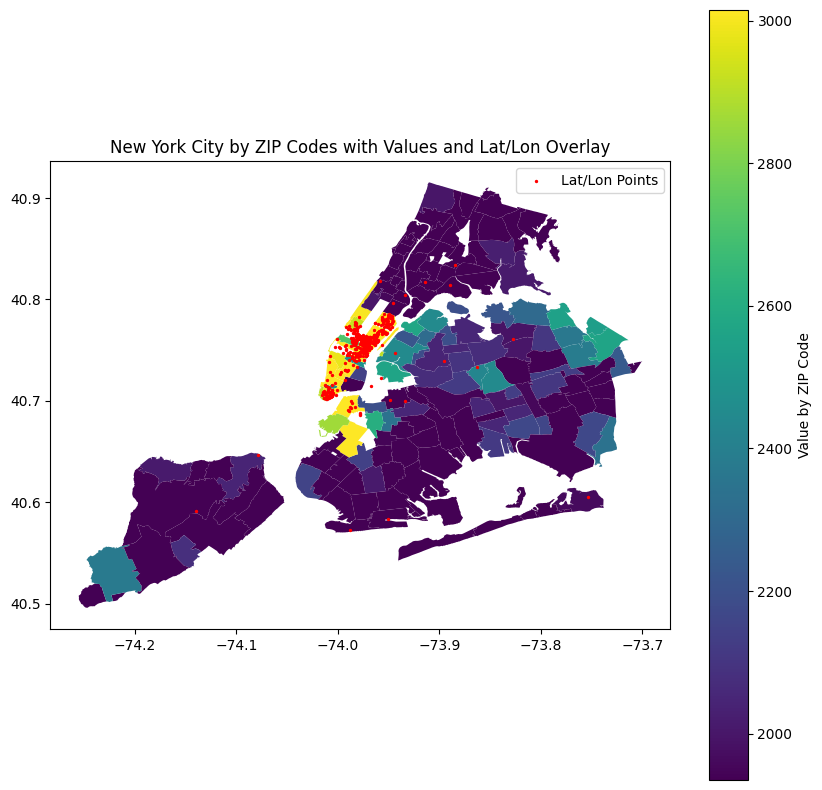

In [54]:
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=gdf['value'].min(), vmax=gdf['value'].max())

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(ax=ax, column='value', cmap=cmap, legend=True, legend_kwds={'label': "Value by ZIP Code", 'orientation': "vertical"})

geometry = [Point(lon, lat) for lon, lat in zip(spaces['Longitude'], spaces['Latitude'])]
lat_lon_gdf = gpd.GeoDataFrame(spaces, geometry=geometry)

# Plot lat/long data points
lat_lon_gdf.plot(ax=ax, color='red', markersize=2, label="Lat/Lon Points")


ax.set_title("New York City by ZIP Codes with Values and Lat/Lon Overlay")
ax.legend()

plt.show()